# Exact FNSPID negative-pressure HAR transfer to LSEG

**Objective.** Apply the unchanged FNSPID market negative-pressure hysteresis
rule to Notebook 46's frozen LSEG HAR base. Test whether the timing improves
return or downside relative to HAR and to an exposure-matched constant.

The LSEG outcome window was already opened. This is a bounded retrospective
mechanism transfer, not independent confirmation or a new strategy search.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.plots import CATEGORICAL, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    build_market_negative_pressure,
    build_market_risk_exposure,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    VolatilityTargetConfig,
    backtest_single_asset_exposure,
    paired_circular_block_mean,
)

apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

SEED = 20260812
BOUNDARY = pd.Timestamp("2025-10-27")
N_FIRMS = 33
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
CONFIG = VolatilityTargetConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=20,
    bootstrap_replications=4_999,
    random_seed=SEED,
)

OUTPUT = ROOT / "final_experiments/outputs/72_lseg_negative_pressure_har_transfer"
SPEC_PATH = ROOT / "final_experiments/frozen_specs/lseg_negative_pressure_har_transfer_v1_20260812.json"
BACKWARD_PATH = ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/backward_finbert_firm_open.parquet"
RECENT_PATH = ROOT / "final_experiments/outputs/67_lseg_gemma_finbert_joined_long_window/recent_finbert_firm_open.parquet"
HAR_PATH = ROOT / "final_experiments/outputs/46_lseg_external_time_har_base_transfer/frozen_har_daily.parquet"
HAR_MANIFEST_PATH = ROOT / "final_experiments/outputs/46_lseg_external_time_har_base_transfer/manifest.json"
OUTPUT.mkdir(parents=True, exist_ok=True)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def bh_qvalues(p_values: list[float] | np.ndarray) -> np.ndarray:
    values = np.asarray(p_values, dtype=float)
    order = np.argsort(values, kind="mergesort")
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0.0, 1.0)
    return adjusted


def annualized_sharpe(values: pd.Series) -> float:
    volatility = float(values.std(ddof=1))
    return float(np.sqrt(252) * values.mean() / volatility) if volatility > 0 else float("nan")


def max_drawdown(values: pd.Series) -> float:
    equity = (1.0 + values).cumprod().to_numpy(dtype=float)
    peak = np.maximum.accumulate(equity)
    return float(np.min(equity / peak - 1.0))


def paired_estimands(
    challenger: pd.DataFrame,
    baseline: pd.DataFrame,
    *,
    comparison: str,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    paired = (
        challenger[["session_date", "net_return"]]
        .rename(columns={"net_return": "challenger_net"})
        .merge(
            baseline[["session_date", "net_return"]].rename(columns={"net_return": "baseline_net"}),
            on="session_date",
            validate="1:1",
        )
        .sort_values("session_date", kind="mergesort")
        .reset_index(drop=True)
    )
    paired["net_difference"] = paired["challenger_net"] - paired["baseline_net"]
    paired["downside_reduction"] = (
        np.minimum(paired["baseline_net"], 0.0) ** 2
        - np.minimum(paired["challenger_net"], 0.0) ** 2
    )
    rows = []
    for offset, (estimand, column) in enumerate(
        (
            ("challenger minus baseline net return", "net_difference"),
            ("baseline minus challenger downside squared return", "downside_reduction"),
        )
    ):
        result = paired_circular_block_mean(
            paired[column],
            block_length=CONFIG.bootstrap_block_length,
            replications=CONFIG.bootstrap_replications,
            seed=seed + offset,
        )
        rows.append({"comparison": comparison, "estimand": estimand, **result})
    return pd.DataFrame(rows), paired


print(f"repo:   {ROOT}")
print(f"output: {OUTPUT}")
print(f"spec:   {SPEC_PATH.relative_to(ROOT)}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/72_lseg_negative_pressure_har_transfer
spec:   final_experiments/frozen_specs/lseg_negative_pressure_har_transfer_v1_20260812.json


## Frozen design

- Pinned FinBERT only.
- Daily pressure is headline-count-weighted negative-story share across a
  complete 33-company session.
- The rolling baseline uses 252 strictly prior sessions with at least 126
  valid observations.
- Enter risk-off at z ≥ 1.5, remain risk-off until z ≤ 0.5, and multiply the
  HAR exposure by 0.25 while risk-off.
- Keep Notebook 46's HAR path, 2 bps/side accounting, and final liquidation.
- Compare against HAR and an exposure-matched constant; test all circular
  placements of the same schedule.

In [2]:
spec = json.loads(SPEC_PATH.read_text())
if spec["status"] != "frozen_before_notebook_72_result":
    raise ValueError("unexpected frozen-spec status")
expected_hashes = {
    BACKWARD_PATH: spec["inputs"]["backward_finbert_firm_open"]["sha256"],
    RECENT_PATH: spec["inputs"]["recent_finbert_firm_open"]["sha256"],
    HAR_PATH: spec["inputs"]["frozen_lseg_har_daily"]["sha256"],
    HAR_MANIFEST_PATH: spec["inputs"]["frozen_lseg_har_manifest"]["sha256"],
}
input_rows = []
for path, expected in expected_hashes.items():
    actual = sha256(path)
    if actual != expected:
        raise ValueError(f"input hash mismatch: {path}")
    input_rows.append(
        {"path": str(path.relative_to(ROOT)), "sha256": actual, "bytes": path.stat().st_size}
    )
input_audit = pd.DataFrame(input_rows)
display(input_audit)

backward = pd.read_parquet(BACKWARD_PATH)
recent = pd.read_parquet(RECENT_PATH)
har_saved = pd.read_parquet(HAR_PATH)
for frame in (backward, recent, har_saved):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
backward = backward.loc[backward["session_date"].lt(BOUNDARY)].copy()
recent = recent.loc[recent["session_date"].ge(BOUNDARY)].copy()

if recent.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate recent firm-open rows")
if not recent.groupby("session_date")["symbol"].nunique().eq(N_FIRMS).all():
    raise ValueError("recent FinBERT panel is not a complete 33-company rectangle")
if har_saved["session_date"].duplicated().any():
    raise ValueError("duplicate HAR daily rows")
if not har_saved["session_date"].equals(
    pd.Series(sorted(recent["session_date"].unique()), name="session_date")
):
    raise ValueError("HAR and recent sentiment sessions do not align")

all_sessions = pd.DatetimeIndex(
    sorted(set(backward["session_date"]) | set(recent["session_date"]))
)
combined = pd.concat([backward, recent], ignore_index=True)
counts = combined.groupby("session_date")["symbol"].nunique().reindex(all_sessions, fill_value=0)
complete_sessions = counts.index[counts.eq(N_FIRMS)]
complete_firm_open = combined.loc[combined["session_date"].isin(complete_sessions)].copy()
complete_firm_open["n"] = complete_firm_open["unique_headline_count"].astype(float)

pressure = build_market_negative_pressure(
    complete_firm_open,
    all_sessions,
    trailing_window=252,
    min_periods=126,
)
exposure_state = build_market_risk_exposure(
    pressure,
    mode="hysteresis",
    entry_z=1.5,
    exit_z=0.5,
    risk_exposure=0.25,
)
recent_state = exposure_state.loc[exposure_state["session_date"].ge(BOUNDARY)].copy()
if not recent_state["session_date"].reset_index(drop=True).equals(har_saved["session_date"]):
    raise ValueError("recent pressure state does not align with HAR")
if recent_state["negative_pressure_z"].isna().any():
    raise ValueError("recent decision window has incomplete pressure z-scores")

pressure_audit = pd.DataFrame(
    [
        {
            "all_sessions": len(all_sessions),
            "backward_sessions": backward["session_date"].nunique(),
            "recent_sessions": recent["session_date"].nunique(),
            "complete_sessions": len(complete_sessions),
            "incomplete_backward_sessions": int(
                counts.loc[counts.index < BOUNDARY].ne(N_FIRMS).sum()
            ),
            "sessions_with_pressure": int(pressure["negative_pressure"].notna().sum()),
            "sessions_with_z": int(pressure["negative_pressure_z"].notna().sum()),
            "first_z_session": pressure.loc[pressure["negative_pressure_z"].notna(), "session_date"].min(),
            "recent_risk_off_sessions": int(recent_state["risk_off"].sum()),
            "recent_risk_off_share": float(recent_state["risk_off"].mean()),
            "first_recent_z": float(recent_state["negative_pressure_z"].iloc[0]),
            "minimum_recent_z": float(recent_state["negative_pressure_z"].min()),
            "maximum_recent_z": float(recent_state["negative_pressure_z"].max()),
        }
    ]
)
display(pressure_audit)

,path,sha256,bytes
0,final_experiments/outputs/67_lseg_gemma_finber...,745e6cba49c6dc6e256f9a6495b39eee66679231d162b5...,1331578
1,final_experiments/outputs/67_lseg_gemma_finber...,0931e77d73e723985d0a4b1000a1ee9601f7a4f330d2fa...,516870
2,final_experiments/outputs/46_lseg_external_tim...,828a0f4e08b800c8e4e086ed74ae0c33096be830ded38a...,25344
3,final_experiments/outputs/46_lseg_external_tim...,5031eb387755a697e97f878dd1d3abb69694c7ee42b6a1...,14732


,all_sessions,backward_sessions,recent_sessions,complete_sessions,incomplete_backward_sessions,sessions_with_pressure,sessions_with_z,first_z_session,recent_risk_off_sessions,recent_risk_off_share,first_recent_z,minimum_recent_z,maximum_recent_z
0,623,456,167,612,11,612,486,2024-07-03,0,0.000000,-1.552426,-1.736404,1.348955


In [3]:
returns = har_saved[["session_date", "forward_return"]].copy()
har_exposure = har_saved[["session_date", "exposure"]].copy()
recomputed_har = backtest_single_asset_exposure(
    returns,
    har_exposure,
    cost_bps_per_side=COST_BPS,
)
reproduction_columns = ["gross_return", "turnover", "cost", "net_return", "gross_exposure"]
reproduction_errors = {
    column: float((recomputed_har[column] - har_saved[column]).abs().max())
    for column in reproduction_columns
}
if max(reproduction_errors.values()) > 1e-12:
    raise RuntimeError("Notebook 46 HAR path does not reproduce")

modifier = recent_state[["session_date", "risk_off", "negative_pressure_z", "exposure"]].rename(
    columns={"exposure": "sentiment_multiplier"}
)
overlay_exposure = har_exposure.merge(modifier, on="session_date", validate="1:1")
overlay_exposure["base_exposure"] = overlay_exposure["exposure"]
overlay_exposure["exposure"] *= overlay_exposure["sentiment_multiplier"]

constant_multiplier = float(overlay_exposure["exposure"].mean() / har_exposure["exposure"].mean())
constant_exposure = har_exposure.copy()
constant_exposure["exposure"] *= constant_multiplier
if not np.isclose(overlay_exposure["exposure"].mean(), constant_exposure["exposure"].mean()):
    raise RuntimeError("constant comparator is not exposure matched")

exposures = {
    "frozen_har": har_exposure,
    "har_negative_pressure_overlay": overlay_exposure,
    "har_constant_matched_multiplier": constant_exposure,
}
daily_paths = {
    arm: backtest_single_asset_exposure(
        returns,
        exposure[["session_date", "exposure"]],
        cost_bps_per_side=COST_BPS,
    )
    for arm, exposure in exposures.items()
}
results = pd.DataFrame(
    [{"arm": arm, **summarize_weight_backtest(path, config=CONFIG)} for arm, path in daily_paths.items()]
)
display(
    results[
        [
            "arm",
            "mean_gross_exposure",
            "sharpe_gross",
            "sharpe_net",
            "ann_vol_net",
            "total_return_net",
            "max_drawdown",
            "annualized_turnover",
        ]
    ]
)

,arm,mean_gross_exposure,sharpe_gross,sharpe_net,ann_vol_net,total_return_net,max_drawdown,annualized_turnover
0,frozen_har,0.720850,0.271602,0.239561,0.097450,0.012411,-0.077704,7.828610
1,har_negative_pressure_overlay,0.720850,0.271602,0.239561,0.097450,0.012411,-0.077704,7.828610
2,har_constant_matched_multiplier,0.720850,0.271602,0.239561,0.097450,0.012411,-0.077704,7.828610


In [4]:
primary_inference, primary_pair = paired_estimands(
    daily_paths["har_negative_pressure_overlay"],
    daily_paths["frozen_har"],
    comparison="negative_pressure_overlay_vs_frozen_har",
    seed=SEED + 10,
)
primary_inference["q_bh_two_test"] = bh_qvalues(primary_inference["p_two_sided"].to_numpy(dtype=float))
primary_inference["bh_reject_q05"] = primary_inference["q_bh_two_test"].lt(0.05)

matched_inference, matched_pair = paired_estimands(
    daily_paths["har_negative_pressure_overlay"],
    daily_paths["har_constant_matched_multiplier"],
    comparison="negative_pressure_overlay_vs_constant_multiplier",
    seed=SEED + 20,
)
display(primary_inference)
display(matched_inference)

sessions = har_saved["session_date"]
midpoint = len(sessions) // 2
halves = (
    ("first_half", sessions.iloc[0], sessions.iloc[midpoint - 1]),
    ("second_half", sessions.iloc[midpoint], sessions.iloc[-1]),
)
temporal_rows = []
for period, start, end in halves:
    for arm, path in daily_paths.items():
        part = path.loc[path["session_date"].between(start, end)]
        temporal_rows.append(
            {
                "period": period,
                "arm": arm,
                "start": start,
                "end": end,
                "n_sessions": len(part),
                "mean_net_bps_session": float(part["net_return"].mean() * 10_000),
                "sharpe_net": annualized_sharpe(part["net_return"]),
                "total_return_net": float((1.0 + part["net_return"]).prod() - 1.0),
                "max_drawdown": max_drawdown(part["net_return"]),
            }
        )
temporal = pd.DataFrame(temporal_rows)
display(temporal)

cost_rows = []
for cost in COST_GRID:
    for arm, path in daily_paths.items():
        repriced = reprice_daily(path, cost_bps_per_side=cost)
        summary = summarize_weight_backtest(repriced, config=CONFIG)
        cost_rows.append(
            {
                "cost_bps_per_side": cost,
                "arm": arm,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)

,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05
0,negative_pressure_overlay_vs_frozen_har,challenger minus baseline net return,167,0.000000,0.000000,0.000000,1.000000,20,4999,20260822,1.000000,False
1,negative_pressure_overlay_vs_frozen_har,baseline minus challenger downside squared return,167,0.000000,0.000000,0.000000,1.000000,20,4999,20260823,1.000000,False


,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,negative_pressure_overlay_vs_constant_multiplier,challenger minus baseline net return,167,0.000000,0.000000,0.000000,1.000000,20,4999,20260832
1,negative_pressure_overlay_vs_constant_multiplier,baseline minus challenger downside squared return,167,0.000000,0.000000,0.000000,1.000000,20,4999,20260833


,period,arm,start,end,n_sessions,mean_net_bps_session,sharpe_net,total_return_net,max_drawdown
0,first_half,frozen_har,2025-10-27,2026-02-25,83,-1.904138,-0.519442,-0.017051,-0.038976
1,first_half,har_negative_pressure_overlay,2025-10-27,2026-02-25,83,-1.904138,-0.519442,-0.017051,-0.038976
2,first_half,har_constant_matched_multiplier,2025-10-27,2026-02-25,83,-1.904138,-0.519442,-0.017051,-0.038976
3,second_half,frozen_har,2026-02-26,2026-06-26,84,3.723234,0.914675,0.029974,-0.055944
4,second_half,har_negative_pressure_overlay,2026-02-26,2026-06-26,84,3.723234,0.914675,0.029974,-0.055944
5,second_half,har_constant_matched_multiplier,2026-02-26,2026-06-26,84,3.723234,0.914675,0.029974,-0.055944


In [5]:
observed_modifier = modifier["sentiment_multiplier"].to_numpy(dtype=float)
shift_rows = []
for shift in range(len(observed_modifier)):
    shifted_exposure = har_exposure.copy()
    shifted_exposure["exposure"] *= np.roll(observed_modifier, shift)
    candidate = backtest_single_asset_exposure(
        returns,
        shifted_exposure,
        cost_bps_per_side=COST_BPS,
    )
    pair = candidate[["session_date", "net_return"]].rename(
        columns={"net_return": "challenger_net"}
    ).merge(
        daily_paths["frozen_har"][["session_date", "net_return"]].rename(
            columns={"net_return": "baseline_net"}
        ),
        on="session_date",
        validate="1:1",
    )
    pair["net_difference"] = pair["challenger_net"] - pair["baseline_net"]
    pair["downside_reduction"] = (
        np.minimum(pair["baseline_net"], 0.0) ** 2
        - np.minimum(pair["challenger_net"], 0.0) ** 2
    )
    shift_rows.append(
        {
            "shift": shift,
            "mean_net_difference": float(pair["net_difference"].mean()),
            "downside_reduction": float(pair["downside_reduction"].mean()),
        }
    )
shift_null = pd.DataFrame(shift_rows)
observed = shift_null.loc[shift_null["shift"].eq(0)].iloc[0]
nonzero = shift_null.loc[shift_null["shift"].ne(0)]
timing_tests = pd.DataFrame(
    [
        {
            "estimand": "overlay minus HAR net return",
            "observed": observed["mean_net_difference"],
            "nonzero_shift_mean": nonzero["mean_net_difference"].mean(),
            "observed_minus_shift_mean": observed["mean_net_difference"] - nonzero["mean_net_difference"].mean(),
            "p_one_sided_exact": float(
                np.mean(shift_null["mean_net_difference"].ge(observed["mean_net_difference"] - 1e-18))
            ),
        },
        {
            "estimand": "HAR minus overlay downside squared return",
            "observed": observed["downside_reduction"],
            "nonzero_shift_mean": nonzero["downside_reduction"].mean(),
            "observed_minus_shift_mean": observed["downside_reduction"] - nonzero["downside_reduction"].mean(),
            "p_one_sided_exact": float(
                np.mean(shift_null["downside_reduction"].ge(observed["downside_reduction"] - 1e-18))
            ),
        },
    ]
)
timing_tests["q_bh_two_test"] = bh_qvalues(timing_tests["p_one_sided_exact"].to_numpy(dtype=float))
display(timing_tests)

,estimand,observed,nonzero_shift_mean,observed_minus_shift_mean,p_one_sided_exact,q_bh_two_test
0,overlay minus HAR net return,0.000000,0.000000,0.000000,1.000000,1.000000
1,HAR minus overlay downside squared return,0.000000,0.000000,0.000000,1.000000,1.000000


In [6]:
result_index = results.set_index("arm")
har_result = result_index.loc["frozen_har"]
overlay_result = result_index.loc["har_negative_pressure_overlay"]
return_test = primary_inference.loc[
    primary_inference["estimand"].eq("challenger minus baseline net return")
].iloc[0]
downside_test = primary_inference.loc[
    primary_inference["estimand"].eq("baseline minus challenger downside squared return")
].iloc[0]

incremental_halves = (
    primary_pair.assign(
        period=np.where(
            primary_pair["session_date"].le(sessions.iloc[midpoint - 1]),
            "first_half",
            "second_half",
        )
    )
    .groupby("period", as_index=False)
    .agg(
        overlay_minus_har_bps_session=("net_difference", lambda values: float(values.mean() * 10_000)),
        downside_reduction_bps2_session=("downside_reduction", lambda values: float(values.mean() * 100_000_000)),
    )
)
overlay_half_sharpes = temporal.loc[
    temporal["arm"].eq("har_negative_pressure_overlay"), "sharpe_net"
]
sharpe_improvement = float(overlay_result["sharpe_net"] - har_result["sharpe_net"])
drawdown_relative_improvement = float(
    (abs(har_result["max_drawdown"]) - abs(overlay_result["max_drawdown"]))
    / abs(har_result["max_drawdown"])
)
return_gate = bool(
    return_test["ci_low"] > 0
    and return_test["q_bh_two_test"] < 0.05
    and sharpe_improvement >= 0.10
    and incremental_halves["overlay_minus_har_bps_session"].ge(0).all()
)
useful_risk_gate = bool(
    downside_test["ci_low"] > 0
    and downside_test["q_bh_two_test"] < 0.05
    and drawdown_relative_improvement >= 0.10
    and return_test["ci_low"] >= -0.0001
    and overlay_half_sharpes.ge(0).all()
)
downside_timing = timing_tests.loc[
    timing_tests["estimand"].eq("HAR minus overlay downside squared return")
].iloc[0]
timing_gate = bool(
    downside_timing["observed_minus_shift_mean"] > 0
    and downside_timing["q_bh_two_test"] < 0.05
)
cross_source_support = bool(useful_risk_gate and timing_gate)
gates = pd.DataFrame(
    [
        {
            "return_gate": return_gate,
            "useful_risk_gate": useful_risk_gate,
            "timing_gate": timing_gate,
            "cross_source_support": cross_source_support,
            "sharpe_improvement": sharpe_improvement,
            "drawdown_relative_improvement": drawdown_relative_improvement,
            "return_ci_low_bps_session": float(return_test["ci_low"] * 10_000),
            "downside_ci_low_bps2_session": float(downside_test["ci_low"] * 100_000_000),
            "risk_off_sessions": int(recent_state["risk_off"].sum()),
        }
    ]
)
display(incremental_halves)
display(gates)

,period,overlay_minus_har_bps_session,downside_reduction_bps2_session
0,first_half,0.000000,0.000000
1,second_half,0.000000,0.000000


,return_gate,useful_risk_gate,timing_gate,cross_source_support,sharpe_improvement,drawdown_relative_improvement,return_ci_low_bps_session,downside_ci_low_bps2_session,risk_off_sessions
0,False,False,False,False,0.000000,0.000000,0.000000,0.000000,0


findfont: Failed to find font weight medium, now using 400.


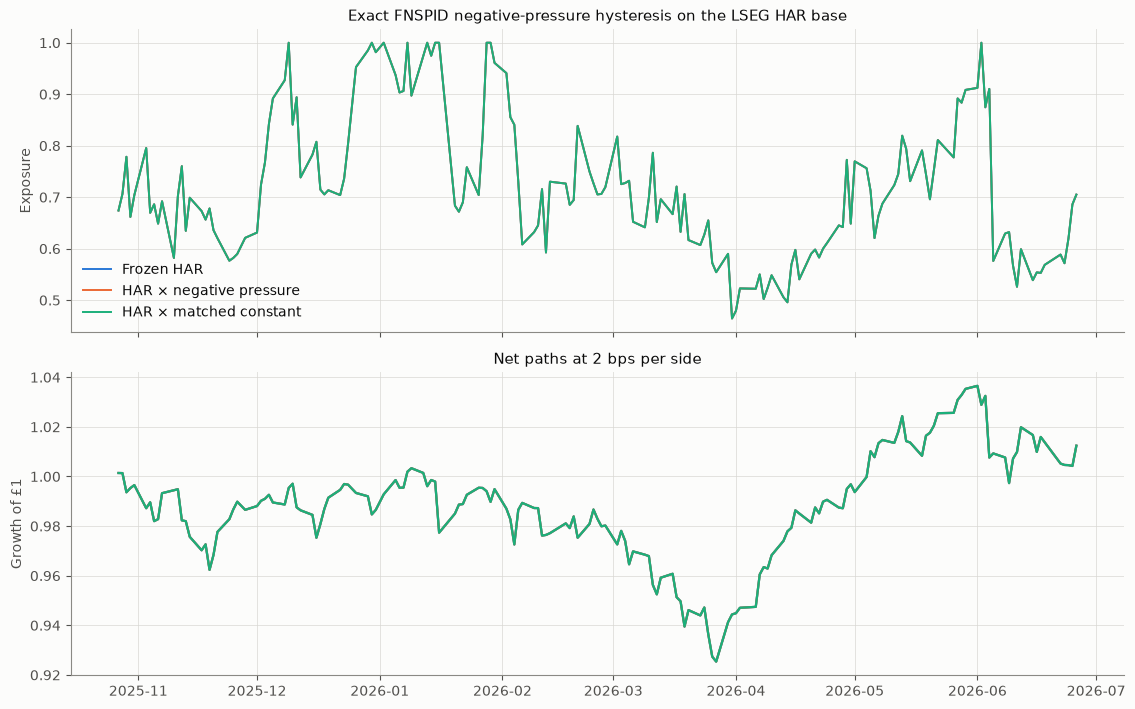

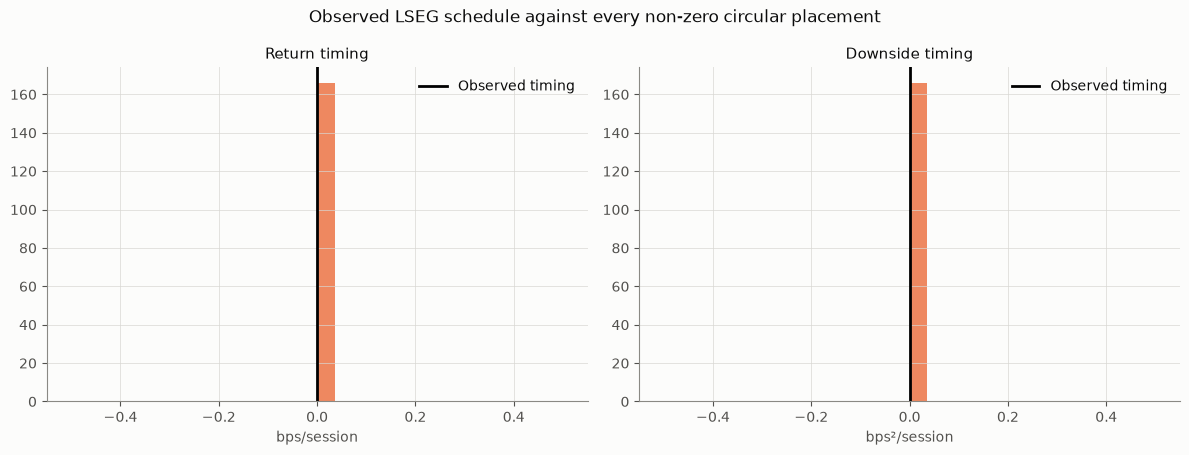

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
for arm, label, colour in (
    ("frozen_har", "Frozen HAR", CATEGORICAL[0]),
    ("har_negative_pressure_overlay", "HAR × negative pressure", CATEGORICAL[1]),
    ("har_constant_matched_multiplier", "HAR × matched constant", CATEGORICAL[2]),
):
    exposure = exposures[arm]
    path = daily_paths[arm]
    axes[0].plot(exposure["session_date"], exposure["exposure"], label=label, color=colour, linewidth=1.4)
    axes[1].plot(
        path["session_date"],
        (1.0 + path["net_return"]).cumprod(),
        label=label,
        color=colour,
        linewidth=1.6,
    )
axes[0].set_ylabel("Exposure")
axes[0].set_title("Exact FNSPID negative-pressure hysteresis on the LSEG HAR base")
axes[0].legend(loc="lower left")
axes[1].set_ylabel("Growth of £1")
axes[1].set_title("Net paths at 2 bps per side")
fig.tight_layout()
fig.savefig(OUTPUT / "exposure_and_equity.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
for axis, column, title, scale in (
    (axes[0], "mean_net_difference", "Return timing", 10_000),
    (axes[1], "downside_reduction", "Downside timing", 100_000_000),
):
    axis.hist(nonzero[column] * scale, bins=28, color=CATEGORICAL[1], alpha=0.78)
    axis.axvline(observed[column] * scale, color="black", linewidth=2, label="Observed timing")
    axis.set_title(title)
    axis.set_xlabel("bps/session" if column == "mean_net_difference" else "bps²/session")
    axis.legend()
fig.suptitle("Observed LSEG schedule against every non-zero circular placement")
fig.tight_layout()
fig.savefig(OUTPUT / "timing_placebo.png", dpi=180, bbox_inches="tight")
plt.show()

In [8]:
input_audit.to_csv(OUTPUT / "input_audit.csv", index=False)
pressure_audit.to_csv(OUTPUT / "pressure_audit.csv", index=False)
pressure.to_parquet(OUTPUT / "daily_negative_pressure.parquet", index=False)
recent_state.to_csv(OUTPUT / "recent_hysteresis_state.csv", index=False)
pd.DataFrame([reproduction_errors]).to_csv(OUTPUT / "har_reproduction_audit.csv", index=False)
results.to_csv(OUTPUT / "strategy_results.csv", index=False)
primary_inference.to_csv(OUTPUT / "primary_inference.csv", index=False)
matched_inference.to_csv(OUTPUT / "matched_exposure_inference.csv", index=False)
temporal.to_csv(OUTPUT / "temporal_results.csv", index=False)
incremental_halves.to_csv(OUTPUT / "incremental_halves.csv", index=False)
cost_curve.to_csv(OUTPUT / "cost_curve.csv", index=False)
shift_null.to_csv(OUTPUT / "circular_shift_null.csv", index=False)
timing_tests.to_csv(OUTPUT / "timing_tests.csv", index=False)
gates.to_csv(OUTPUT / "gates.csv", index=False)
for arm, path in daily_paths.items():
    path.to_parquet(OUTPUT / f"{arm}_daily.parquet", index=False)

git_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=ROOT, check=True, capture_output=True, text=True
).stdout.strip()
manifest = {
    "notebook": "72_lseg_negative_pressure_har_transfer",
    "status": "complete_bounded_retrospective_cross_source_mechanism_transfer",
    "git_commit_at_execution": git_commit,
    "frozen_spec": str(SPEC_PATH.relative_to(ROOT)),
    "input_hashes": {str(path.relative_to(ROOT)): digest for path, digest in expected_hashes.items()},
    "sentiment_rule": spec["sentiment_rule"],
    "portfolio": spec["portfolio"],
    "strategy_results": json.loads(results.to_json(orient="records")),
    "primary_inference": json.loads(primary_inference.to_json(orient="records")),
    "matched_exposure_inference": json.loads(matched_inference.to_json(orient="records")),
    "timing_tests": json.loads(timing_tests.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "claim_boundaries": spec["claim_boundaries"],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

display(
    Markdown(
        f"""### Decision

The exact LSEG negative-pressure transfer **{'supports' if cross_source_support else 'does not support'}**
the FNSPID risk-timing mechanism on this already-opened 167-session window.

- HAR net Sharpe: **{har_result['sharpe_net']:.3f}**.
- HAR × negative-pressure net Sharpe: **{overlay_result['sharpe_net']:.3f}**
  (change **{sharpe_improvement:+.3f}**).
- Overlay-minus-HAR net return: **{return_test['mean'] * 10_000:+.3f} bps/session**
  (95% block interval **[{return_test['ci_low'] * 10_000:+.3f}, {return_test['ci_high'] * 10_000:+.3f}]**,
  BH q=**{return_test['q_bh_two_test']:.4f}**).
- HAR-minus-overlay downside squared return: **{downside_test['mean'] * 100_000_000:+.2f} bps²/session**
  (95% block interval **[{downside_test['ci_low'] * 100_000_000:+.2f}, {downside_test['ci_high'] * 100_000_000:+.2f}]**,
  BH q=**{downside_test['q_bh_two_test']:.4f}**).
- Risk-off sessions: **{int(recent_state['risk_off'].sum())}/{len(recent_state)}**;
  circular-shift downside timing BH q=**{downside_timing['q_bh_two_test']:.4f}**.

No threshold, scorer, window, cost, or exposure parameter is changed after this result.
"""
    )
)

### Decision

The exact LSEG negative-pressure transfer **does not support**
the FNSPID risk-timing mechanism on this already-opened 167-session window.

- HAR net Sharpe: **0.240**.
- HAR × negative-pressure net Sharpe: **0.240**
  (change **+0.000**).
- Overlay-minus-HAR net return: **+0.000 bps/session**
  (95% block interval **[+0.000, +0.000]**,
  BH q=**1.0000**).
- HAR-minus-overlay downside squared return: **+0.00 bps²/session**
  (95% block interval **[+0.00, +0.00]**,
  BH q=**1.0000**).
- Risk-off sessions: **0/167**;
  circular-shift downside timing BH q=**1.0000**.

No threshold, scorer, window, cost, or exposure parameter is changed after this result.


## Next step

Refresh the synthesis and live research records. Treat any failure here as a
portability limit, not as permission to reverse sentiment or search another
LSEG threshold.